# 01c -- Baseline Definitivo | SWaT A1/A2 (Optuna)

Carga la mejor configuracion de hiperparametros encontrada por el
estudio Optuna (01b) y reentrena el modelo completo con todas las
visualizaciones y metricas de analisis exhaustivo.

| Version | Config | F1 | AUC |
|---------|--------|----|-----|
| 01a baseline v1 | Manual | 0.757 | 0.817 |
| **01c baseline v2** | **Optuna** | **TBD** | **TBD** |

### Protocolo de evaluacion

- Exclusiones: ninguna por defecto (el dataset A1/A2 es la referencia).
- Filtro consecutivo: k=3.
- Sweep de tau (800 puntos) para umbral optimo.
- Metricas internas (val ELBO) y externas (ROC-AUC, F1, PR, FPR).


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

CLEAN_DIR   = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
NORMAL_XLSX = CLEAN_DIR / 'SWaT_Dataset_Normal_v1.xlsx'
ATTACK_XLSX = CLEAN_DIR / 'SWaT_Dataset_Attack_v0.xlsx'

OPTUNA_CFG  = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_optuna_v1' / 'optuna_best_config.json'
SAVE_DIR    = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_baseline_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('Normal :', NORMAL_XLSX.exists())
print('Attack :', ATTACK_XLSX.exists())
print('Optuna :', OPTUNA_CFG.exists())
print('Save   :', SAVE_DIR)
ATK_LIST    = CLEAN_DIR / 'List_of_attacks_Final.xlsx'
print('ATK_LIST    :', ATK_LIST.exists())


Normal : True
Attack : True
Optuna : True
Save   : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_baseline_v2
ATK_LIST    : True


## 2. Hiperparametros desde Optuna

In [ ]:
with open(OPTUNA_CFG) as f:
    ocfg = json.load(f)

CONTINUOUS_COLS = ocfg['continuous_cols']
DISCRETE_COLS   = ocfg['discrete_cols']
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS
DISC_DIM        = int(ocfg['disc_summary_dim'])

bp = ocfg['best_params']
WINDOW_SIZE  = int(ocfg['window_size'])
STRIDE       = int(bp['stride'])
CLIP_VAL     = float(ocfg['clip_val'])
WARMUP_SEC   = int(ocfg['warmup_sec'])
CONSEC_K     = int(ocfg['consec_k'])

HIDDEN_SIZE  = int(bp['hidden_size'])
NUM_LAYERS   = 3
LATENT_DIM   = int(bp['latent_dim'])
DISC_HIDDEN  = int(bp['disc_hidden'])
BETA         = float(bp['beta'])
ALPHA        = float(bp['alpha'])
DROPOUT      = float(bp['dropout'])
LR           = float(bp['lr'])
BATCH_SIZE   = int(bp['batch_size'])

MAX_EPOCHS   = 150
PATIENCE     = 20

print(f'--- Configuracion cargada del mejor trial Optuna (#{ocfg["best_trial"]}) ---')
print(f'AUC en Optuna (trial)     : {ocfg["best_auc_trial"]:.4f}')
print(f'AUC en Optuna (retrain)   : {ocfg["best_auc_retrain"]:.4f}')
print(f'Window={WINDOW_SIZE} | Stride={STRIDE} | Clip={CLIP_VAL} | K={CONSEC_K}')
print(f'hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM} | disc_h={DISC_HIDDEN}')
print(f'beta={BETA:.5f} | alpha={ALPHA:.4f} | dropout={DROPOUT:.4f}')
print(f'lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'Sensores: {len(CONTINUOUS_COLS)} cont + {len(DISCRETE_COLS)} disc')

# ── Evaluacion alineada con Pinto et al. (2024) ─────────────────────────────
EXCLUDED_ATTACKS  = [4, 5, 6, 9, 12, 13, 14, 15, 18, 19, 20, 24, 29, 34, 38]
EVALUABLE_ATK_IDS = [i for i in range(1, 42) if i not in EXCLUDED_ATTACKS]
print(f'Ataques evaluables (Pinto et al.): {len(EVALUABLE_ATK_IDS)} / 41')


--- Configuracion cargada del mejor trial Optuna (#13) ---
AUC en Optuna (trial)     : 0.8314
AUC en Optuna (retrain)   : 0.8216
Window=60 | Stride=10 | Clip=5.0 | K=3
hidden=128 | layers=1 | latent=96 | disc_h=128
beta=0.06728 | alpha=0.8775 | dropout=0.2641
lr=1.60e-04 | batch=512
Sensores: 25 cont + 26 disc
Ataques evaluables (Pinto et al.): 26 / 41


## 3. Carga y preprocesamiento

In [5]:
def load_swat_xlsx(path, label_is_string=True):
    df = pd.read_excel(path, header=1)
    df.columns = [c.strip() for c in df.columns]
    df['Timestamp'] = pd.to_datetime(
        df['Timestamp'].astype(str).str.strip(),
        format='%d/%m/%Y %I:%M:%S %p'
    )
    df = df.sort_values('Timestamp').reset_index(drop=True)
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if label_is_string and 'Normal/Attack' in df.columns:
        df['Normal/Attack'] = df['Normal/Attack'].astype(str).str.strip().replace('A ttack','Attack')
        df['attack_label']  = (df['Normal/Attack'] == 'Attack').astype(int)
    else:
        df['attack_label'] = 0
    return df

print('Cargando Normal_v1...')
df_normal = load_swat_xlsx(NORMAL_XLSX, label_is_string=False)
t0_n = df_normal['Timestamp'].min()
df_normal = df_normal[
    df_normal['Timestamp'] >= t0_n + pd.Timedelta(seconds=WARMUP_SEC)
].reset_index(drop=True)

n = len(df_normal)
df_train = df_normal.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_normal.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'  Normal_v1: {len(df_normal):,} filas | '
      f'{df_normal["Timestamp"].min()} -> {df_normal["Timestamp"].max()}')
print(f'  Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

print('Cargando Attack_v0...')
df_attack = load_swat_xlsx(ATTACK_XLSX, label_is_string=True)
print(f'  Attack_v0: {len(df_attack):,} filas | '
      f'Normal={(df_attack["attack_label"]==0).sum():,} | '
      f'Attack={(df_attack["attack_label"]==1).sum():,} ({100*df_attack["attack_label"].mean():.1f}%)')


Cargando Normal_v1...
  Normal_v1: 493,200 filas | 2015-12-22 17:00:00 -> 2015-12-28 09:59:59
  Train: 295,920 | Val: 98,640 | Test: 98,640
Cargando Attack_v0...
  Attack_v0: 449,919 filas | Normal=395,298 | Attack=54,621 (12.1%)


## 4. Escalado

In [6]:
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[CONTINUOUS_COLS].values)
disc_max = df_train[DISCRETE_COLS].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[CONTINUOUS_COLS] = np.clip(
        scaler_cont.transform(df[CONTINUOUS_COLS].values), -CLIP_VAL, CLIP_VAL
    )
    df[DISCRETE_COLS] = (df[DISCRETE_COLS] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')
print(f'Train cont escalado: [{df_train_sc[CONTINUOUS_COLS].values.min():.2f}, '
      f'{df_train_sc[CONTINUOUS_COLS].values.max():.2f}]  (esperado: [-5, 5])')


Train cont escalado: [-5.00, 5.00]  (esperado: [-5, 5])


## 5. Ventanas de entrenamiento

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    wc  = create_windows(df_sc[CONTINUOUS_COLS].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[DISCRETE_COLS].values.astype(np.float32),   ws, stride)
    wds = summarize_discrete_windows(wd, DISCRETE_COLS).values.astype(np.float32)
    return wc, wds

X_tr_c, X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows(df_test_sc,  WINDOW_SIZE, STRIDE)

print(f'Train: {X_tr_c.shape}  (N, T, C)')
print(f'Val  : {X_va_c.shape}')
print(f'Test : {X_te_c.shape}')
print(f'Disc summary dim: {X_tr_d.shape[1]}')
assert X_tr_d.shape[1] == DISC_DIM, f'Disc dim mismatch: {X_tr_d.shape[1]} != {DISC_DIM}'
print('Disc dim OK')


Train: (29587, 60, 25)  (N, T, C)
Val  : (9859, 60, 25)
Test : (9859, 60, 25)
Disc summary dim: 104
Disc dim OK


## 6. Arquitectura LSTM-VAE

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, seq_len, disc_dim, hidden_size=128, num_layers=2,
                 latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        cont_size = len(CONTINUOUS_COLS)
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

model = HybridLSTMVAE(
    seq_len     = WINDOW_SIZE,
    disc_dim    = DISC_DIM,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {n_params:,}')
print(f'  Encoder LSTM: {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM: {sum(p.numel() for p in model.decoder_cont.parameters()):,}')


Parametros totales: 278,913
  Encoder LSTM: 104,128
  Decoder LSTM: 131,353


## 7. Entrenamiento

In [9]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7
)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist, hist_mse_c, hist_mse_d, hist_kl = [], [], [], [], []

print(f'Batch={BATCH_SIZE} | LR={LR:.2e} | MaxEp={MAX_EPOCHS} | Patience={PATIENCE}')
print(f'beta={BETA:.5f} | alpha={ALPHA:.4f}')
print(f'Train batches/ep: {len(train_loader):,}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tl = tmse_c = tmse_d = tkl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat, mu, logvar = model(xc, xd)
        loss, mc, md, kl = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tl += loss.item(); tmse_c += mc.item(); tmse_d += md.item(); tkl += kl.item()

    nb_b = len(train_loader)
    tl /= nb_b; tmse_c /= nb_b; tmse_d /= nb_b; tkl /= nb_b

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    hist_mse_c.append(tmse_c); hist_mse_d.append(tmse_d); hist_kl.append(tkl)

    if vl < best_val - 1e-6:
        best_val = vl; best_ep = epoch; no_improve = 0
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} '
              f'(mse_c={tmse_c:.4f} kl={tkl:.4f}) | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}.'); break

model.load_state_dict(best_wts)
model.eval()
print(f'Mejor val:{best_val:.5f} ep{best_ep}')


Batch=512 | LR=1.60e-04 | MaxEp=150 | Patience=20
beta=0.06728 | alpha=0.8775
Train batches/ep: 57
Ep   10/150 | Train:0.18757 (mse_c=0.1808 kl=0.4502) | Val:0.21944 | Best:0.21944(ep10)
Ep   20/150 | Train:0.15110 (mse_c=0.1429 kl=0.4158) | Val:0.19867 | Best:0.19867(ep20)
Ep   30/150 | Train:0.13812 (mse_c=0.1310 kl=0.3823) | Val:0.19058 | Best:0.19058(ep30)
Ep   40/150 | Train:0.13149 (mse_c=0.1245 kl=0.3699) | Val:0.18412 | Best:0.18412(ep40)
Ep   50/150 | Train:0.12625 (mse_c=0.1199 kl=0.3505) | Val:0.17923 | Best:0.17923(ep50)
Ep   60/150 | Train:0.12384 (mse_c=0.1180 kl=0.3401) | Val:0.17712 | Best:0.17668(ep58)
Ep   70/150 | Train:0.12045 (mse_c=0.1147 kl=0.3328) | Val:0.17784 | Best:0.17536(ep63)
Ep   80/150 | Train:0.11704 (mse_c=0.1121 kl=0.3140) | Val:0.17282 | Best:0.17218(ep78)
Ep   90/150 | Train:0.11484 (mse_c=0.1102 kl=0.3050) | Val:0.17013 | Best:0.17013(ep90)
Ep  100/150 | Train:0.11194 (mse_c=0.1077 kl=0.2927) | Val:0.16877 | Best:0.16877(ep100)
Ep  110/150 | Train:

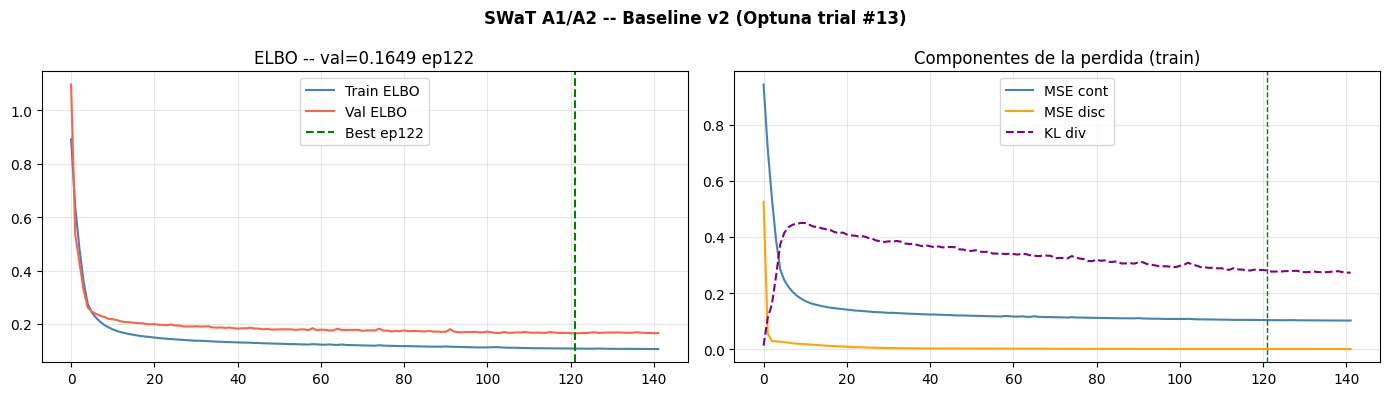

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_hist, label='Train ELBO', color='steelblue', lw=1.5)
axes[0].plot(val_hist,   label='Val ELBO',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title(f'ELBO -- val={best_val:.4f} ep{best_ep}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_mse_c, label='MSE cont', color='steelblue', lw=1.5)
axes[1].plot(hist_mse_d, label='MSE disc', color='orange',    lw=1.5)
axes[1].plot(hist_kl,    label='KL div',   color='purple',    lw=1.5, linestyle='--')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1)
axes[1].set_title('Componentes de la perdida (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'SWaT A1/A2 -- Baseline v2 (Optuna trial #{ocfg["best_trial"]})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 8. Evaluacion supervisada con Attack_v0

### 8a. Ventanas de evaluacion

In [ ]:
# Cargar lista de ataques y asignar attack_id por timestamps
df_atk_list = pd.read_excel(ATK_LIST)
df_atk_list = df_atk_list[
    pd.to_numeric(df_atk_list['Attack #'], errors='coerce').notna()
].copy()
df_atk_list['Attack #'] = df_atk_list['Attack #'].astype(int)
df_atk_list['start_dt'] = pd.to_datetime(
    df_atk_list['Start Time'].astype(str).str.strip(), errors='coerce'
)


# Escalar Attack_v0
df_eval_sc = df_attack.copy()
df_eval_sc[CONTINUOUS_COLS] = np.clip(
    scaler_cont.transform(df_eval_sc[CONTINUOUS_COLS].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[DISCRETE_COLS] = (df_eval_sc[DISCRETE_COLS] / disc_max).clip(0, 1)

# Fix para ataques en frontera de año (diciembre 2015 / enero 2016)
def parse_end_fixed(row):
    et = str(row['End Time']).strip()
    if et in ('nan', 'NaT', ''): return pd.NaT
    st = row['start_dt']
    if pd.isna(st): return pd.NaT
    try:
        t   = pd.to_datetime(et, format='%H:%M:%S').time()
        end = pd.Timestamp.combine(st.date(), t)
        # Si la hora de fin es menor que la de inicio, cruza medianoche
        if end < st:
            end += pd.Timedelta(days=1)
        return end
    except:
        return pd.NaT

# Ataques 37-41 ocurren en enero 2016; si start_dt viene como 2015, corregir
for idx, row in df_atk_list.iterrows():
    if pd.notna(row['start_dt']) and row['start_dt'].year == 2015:
        # Verificar si debería ser 2016 comparando con el rango del CSV
        ts_max = df_eval_sc['Timestamp'].max()
        if ts_max.year == 2016 and row['start_dt'].month == 1:
            df_atk_list.at[idx, 'start_dt'] = row['start_dt'].replace(year=2016)

df_atk_list['end_dt'] = df_atk_list.apply(parse_end_fixed, axis=1)


# Asignar attack_id por timestamps
df_eval_sc['attack_id'] = 0
for _, row in df_atk_list.iterrows():
    aid = int(row['Attack #'])
    if pd.isna(row['start_dt']) or pd.isna(row['end_dt']): continue
    mask = ((df_eval_sc['Timestamp'] >= row['start_dt']) &
            (df_eval_sc['Timestamp'] <= row['end_dt']))
    df_eval_sc.loc[mask, 'attack_id'] = aid

labs_arr  = df_eval_sc['attack_label'].values
ts_arr    = df_eval_sc['Timestamp'].values
aid_arr   = df_eval_sc['attack_id'].values
cont_arr  = df_eval_sc[CONTINUOUS_COLS].values.astype(np.float32)
disc_arr  = df_eval_sc[DISCRETE_COLS].values.astype(np.float32)

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    atk_aids = seg_aids[seg_labs==1]
    if len(atk_aids) > 0:
        uid, cnt = np.unique(atk_aids, return_counts=True)
        aid_mode = int(uid[cnt.argmax()])
    else:
        aid_mode = 0
    meta_rows.append({
        'y': int(np.any(seg_labs==1)),
        'attack_id': aid_mode,
        'attack_frac': float(np.mean(seg_labs==1)),
        't_start': ts_arr[s],
    })

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(
    np.array(wins_d, dtype=np.float32), DISCRETE_COLS
).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)
y_all    = df_wins['y'].values

print(f'Ventanas eval: {len(df_wins):,}')
print(f'  Normal (y=0): {(y_all==0).sum():,}')
print(f'  Ataque (y=1): {(y_all==1).sum():,}  ({100*y_all.mean():.1f}%)')
assert len(X_eval_c) == len(y_all)
print('Shape OK')


Ventanas eval: 44,986
  Normal (y=0): 39,320
  Ataque (y=1): 5,666  (12.6%)
Shape OK


### 8b. Scores y distribucion de referencia

MAE medio NORMAL: 0.78075
MAE medio ATAQUE: 1.81305  (ratio: 2.32x)
ROC-AUC referencia (todos los ataques): 0.8204


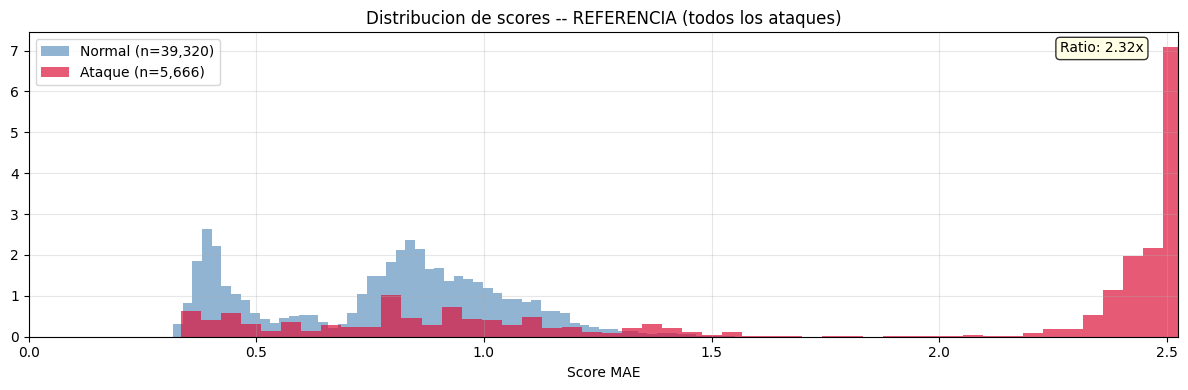

In [12]:
def recon_scores(model, Xc, Xd, alpha, bs=512):
    """Score = alpha*MAE_cont + (1-alpha)*MAE_disc (Pinto et al. 2024)."""
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in ldr:
            xc, xd = xc.to(device), xd.to(device)
            xc_h, xd_h, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean(torch.abs(xc_h - xc), dim=(1, 2)).cpu().numpy())
            ed_l.extend(torch.mean(torch.abs(xd_h - xd), dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed

scores   = recon_scores(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores

mn = scores[y_all==0].mean(); ma = scores[y_all==1].mean()
print(f'MAE medio NORMAL: {mn:.5f}')
print(f'MAE medio ATAQUE: {ma:.5f}  (ratio: {ma/mn:.2f}x)')
print(f'ROC-AUC referencia (todos los ataques): {roc_auc_score(y_all, scores):.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores[y_all==0], bins=100, alpha=0.6, density=True, color='steelblue',
        label=f'Normal (n={(y_all==0).sum():,})')
ax.hist(scores[y_all==1], bins=50,  alpha=0.7, density=True, color='crimson',
        label=f'Ataque (n={(y_all==1).sum():,})')
ax.text(0.97, 0.97, f'Ratio: {ma/mn:.2f}x', ha='right', va='top',
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_xlabel('Score MAE'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Distribucion de scores -- REFERENCIA (todos los ataques)')
ax.set_xlim(0, np.percentile(scores, 99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'error_dist_referencia.png'), dpi=120, bbox_inches='tight')
plt.show()


### 8c. Protocolo definitivo: sweep de tau + filtro k=3

In [13]:
def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out

# Excluir ataques sin impacto fisico/fallidos (Pinto et al. 2024)
keep    = ~((df_wins['y']==1) & (~df_wins['attack_id'].isin(EVALUABLE_ATK_IDS)))
sc_filt = scores[keep.values]
y_filt  = y_all[keep.values]
print(f'Ventanas filtradas (26 ataques evaluables): {len(sc_filt):,}')

taus_sw = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_f1, sw_prec, sw_rec, sw_fpr = [], [], [], []
for tau in taus_sw:
    pr = consec_filter(sc_filt, tau, CONSEC_K)
    tp_ = ((pr==1)&(y_filt==1)).sum(); fp_ = ((pr==1)&(y_filt==0)).sum()
    fn_ = ((pr==0)&(y_filt==1)).sum(); tn_ = ((pr==0)&(y_filt==0)).sum()
    p_ = tp_/(tp_+fp_+1e-10); r_ = tp_/(tp_+fn_+1e-10)
    sw_f1.append(2*p_*r_/(p_+r_+1e-10))
    sw_prec.append(p_); sw_rec.append(r_); sw_fpr.append(fp_/(fp_+tn_+1e-10))

sw_f1 = np.array(sw_f1)
best_idx = sw_f1.argmax()
TAU_OPT  = float(taus_sw[best_idx])

pred_f = consec_filter(sc_filt, TAU_OPT, CONSEC_K)
tp = int(((pred_f==1)&(y_filt==1)).sum())
fp = int(((pred_f==1)&(y_filt==0)).sum())
fn = int(((pred_f==0)&(y_filt==1)).sum())
tn = int(((pred_f==0)&(y_filt==0)).sum())
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)
auc_filt  = roc_auc_score(y_filt, sc_filt)
pr_auc    = average_precision_score(y_filt, sc_filt)

print('='*65)
print('METRICAS BASELINE v2 -- SWaT A1/A2 (Optuna)')
print('='*65)
print(f'  Optuna trial   : #{ocfg["best_trial"]} | AUC trial={ocfg["best_auc_trial"]:.4f}')
print(f'  Protocolo      : k={CONSEC_K} | tau={TAU_OPT:.5f}')
print()
print(f'  ROC-AUC  : {auc_filt:.4f}   PR-AUC  : {pr_auc:.4f}')
print(f'  F1       : {f1:.3f}     Recall  : {rec:.3f}')
print(f'  Precision: {prec:.3f}     FPR     : {fpr:.3f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print()
print(f'  --- Comparativa vs baseline v1 ---')
print(f'  AUC : v1=0.8170 -> v2={auc_filt:.4f}  ({auc_filt-0.817:+.4f})')
print(f'  F1  : v1=0.757  -> v2={f1:.3f}   ({f1-0.757:+.3f})')
print(f'  Rec : v1=0.615  -> v2={rec:.3f}   ({rec-0.615:+.3f})')
print('='*65)


Ventanas filtradas (26 ataques evaluables): 44,270
METRICAS BASELINE v2 -- SWaT A1/A2 (Optuna)
  Optuna trial   : #13 | AUC trial=0.8314
  Protocolo      : k=3 | tau=1.50551

  ROC-AUC  : 0.8603   PR-AUC  : 0.7756
  F1       : 0.798     Recall  : 0.668
  Precision: 0.992     FPR     : 0.001
  TP=3305 | FP=25 | FN=1645 | TN=39295

  --- Comparativa vs baseline v1 ---
  AUC : v1=0.8170 -> v2=0.8603  (+0.0433)
  F1  : v1=0.757  -> v2=0.798   (+0.041)
  Rec : v1=0.615  -> v2=0.668   (+0.053)


### 8d. Visualizaciones completas

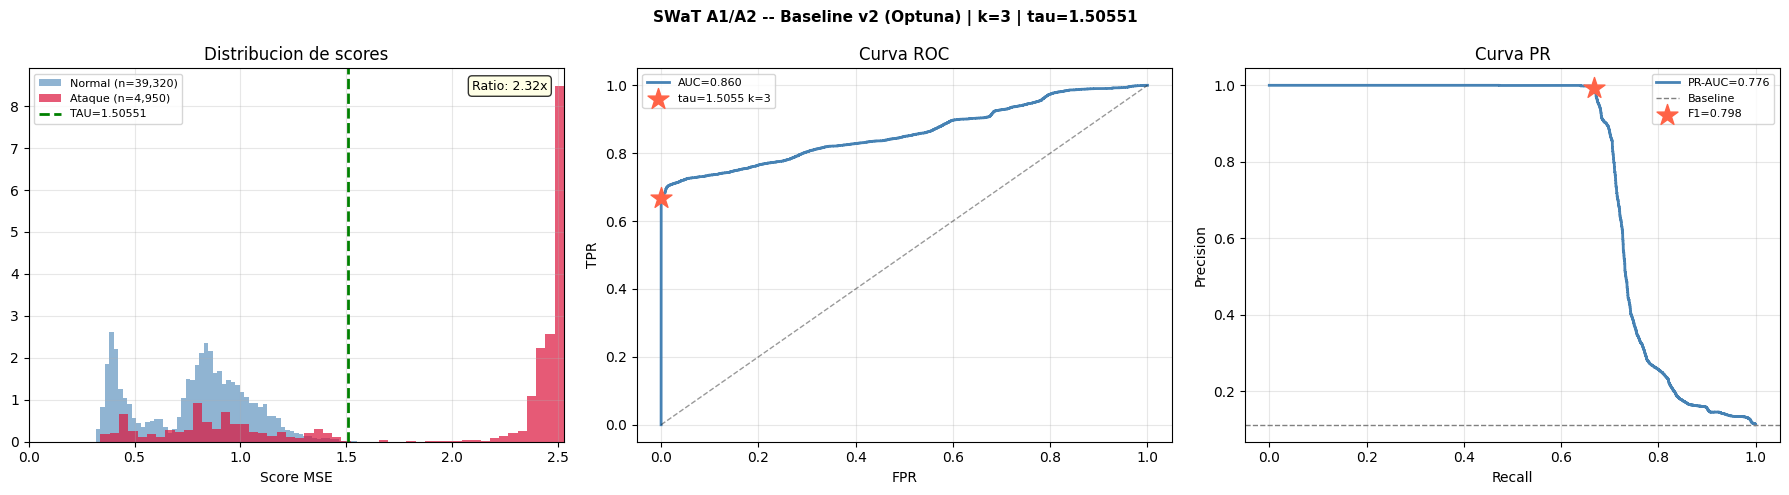

In [14]:
# Distribucion filtrada + ROC + PR
fprs_c, tprs_c, _ = roc_curve(y_filt, sc_filt)
precs_c, recs_c, _ = precision_recall_curve(y_filt, sc_filt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sc_filt[y_filt==0], bins=100, alpha=0.6, density=True, color='steelblue',
             label=f'Normal (n={(y_filt==0).sum():,})')
axes[0].hist(sc_filt[y_filt==1], bins=50,  alpha=0.7, density=True, color='crimson',
             label=f'Ataque (n={(y_filt==1).sum():,})')
axes[0].axvline(TAU_OPT, color='green', lw=2, linestyle='--', label=f'TAU={TAU_OPT:.5f}')
axes[0].text(0.97, 0.97, f'Ratio: {ma/mn:.2f}x', ha='right', va='top',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8), fontsize=9)
axes[0].set_xlabel('Score MSE'); axes[0].set_title('Distribucion de scores')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, np.percentile(sc_filt, 99.5))

axes[1].plot(fprs_c, tprs_c, color='steelblue', lw=2, label=f'AUC={auc_filt:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[1].scatter(fpr, rec, marker='*', s=250, color='tomato', zorder=5,
                label=f'tau={TAU_OPT:.4f} k={CONSEC_K}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(recs_c, precs_c, color='steelblue', lw=2, label=f'PR-AUC={pr_auc:.3f}')
axes[2].axhline(y_filt.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].scatter(rec, prec, marker='*', s=250, color='tomato', zorder=5,
                label=f'F1={f1:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Curva PR'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'SWaT A1/A2 -- Baseline v2 (Optuna) | k={CONSEC_K} | tau={TAU_OPT:.5f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'eval_dist_roc_pr.png'), dpi=120, bbox_inches='tight')
plt.show()


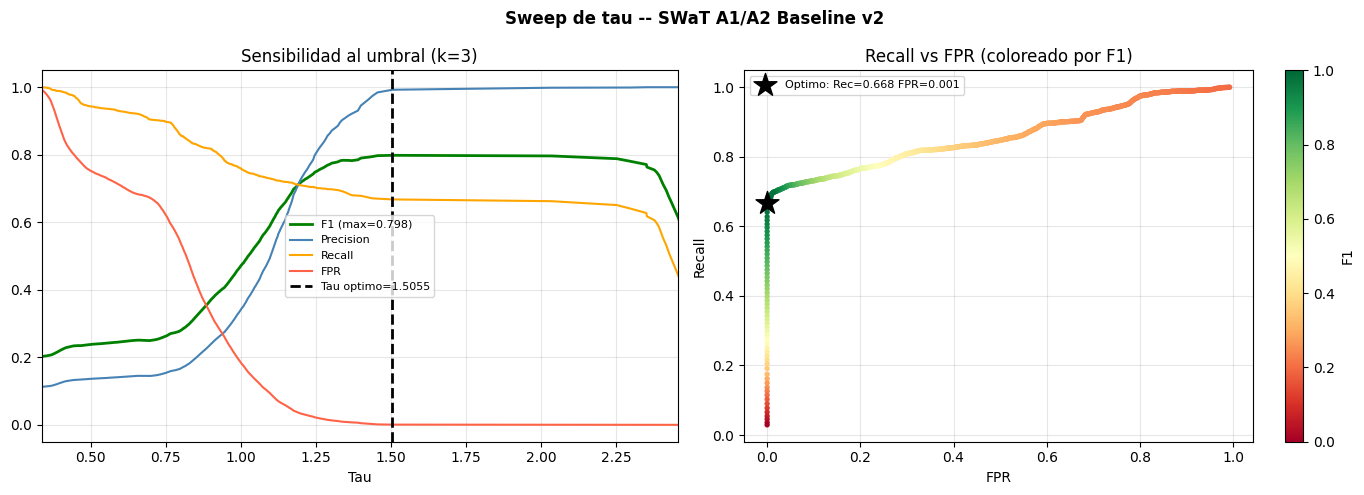

In [15]:
# Sweep de tau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(taus_sw, sw_f1,                  color='green',     lw=2,   label=f'F1 (max={sw_f1.max():.3f})')
axes[0].plot(taus_sw, np.array(sw_prec),       color='steelblue', lw=1.5, label='Precision')
axes[0].plot(taus_sw, np.array(sw_rec),        color='orange',    lw=1.5, label='Recall')
axes[0].plot(taus_sw, np.array(sw_fpr),        color='tomato',    lw=1.5, label='FPR')
axes[0].axvline(TAU_OPT, color='black', lw=2, linestyle='--', label=f'Tau optimo={TAU_OPT:.4f}')
axes[0].set_xlabel('Tau'); axes[0].set_xlim(taus_sw[0], np.percentile(sc_filt, 95))
axes[0].set_title(f'Sensibilidad al umbral (k={CONSEC_K})')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].scatter(sw_fpr, sw_rec, c=sw_f1, cmap='RdYlGn', s=8, zorder=3)
axes[1].scatter(sw_fpr[best_idx], sw_rec[best_idx], marker='*', s=300, color='black',
                zorder=5, label=f'Optimo: Rec={sw_rec[best_idx]:.3f} FPR={sw_fpr[best_idx]:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall vs FPR (coloreado por F1)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn'), ax=axes[1], label='F1')

plt.suptitle('Sweep de tau -- SWaT A1/A2 Baseline v2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'tau_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()


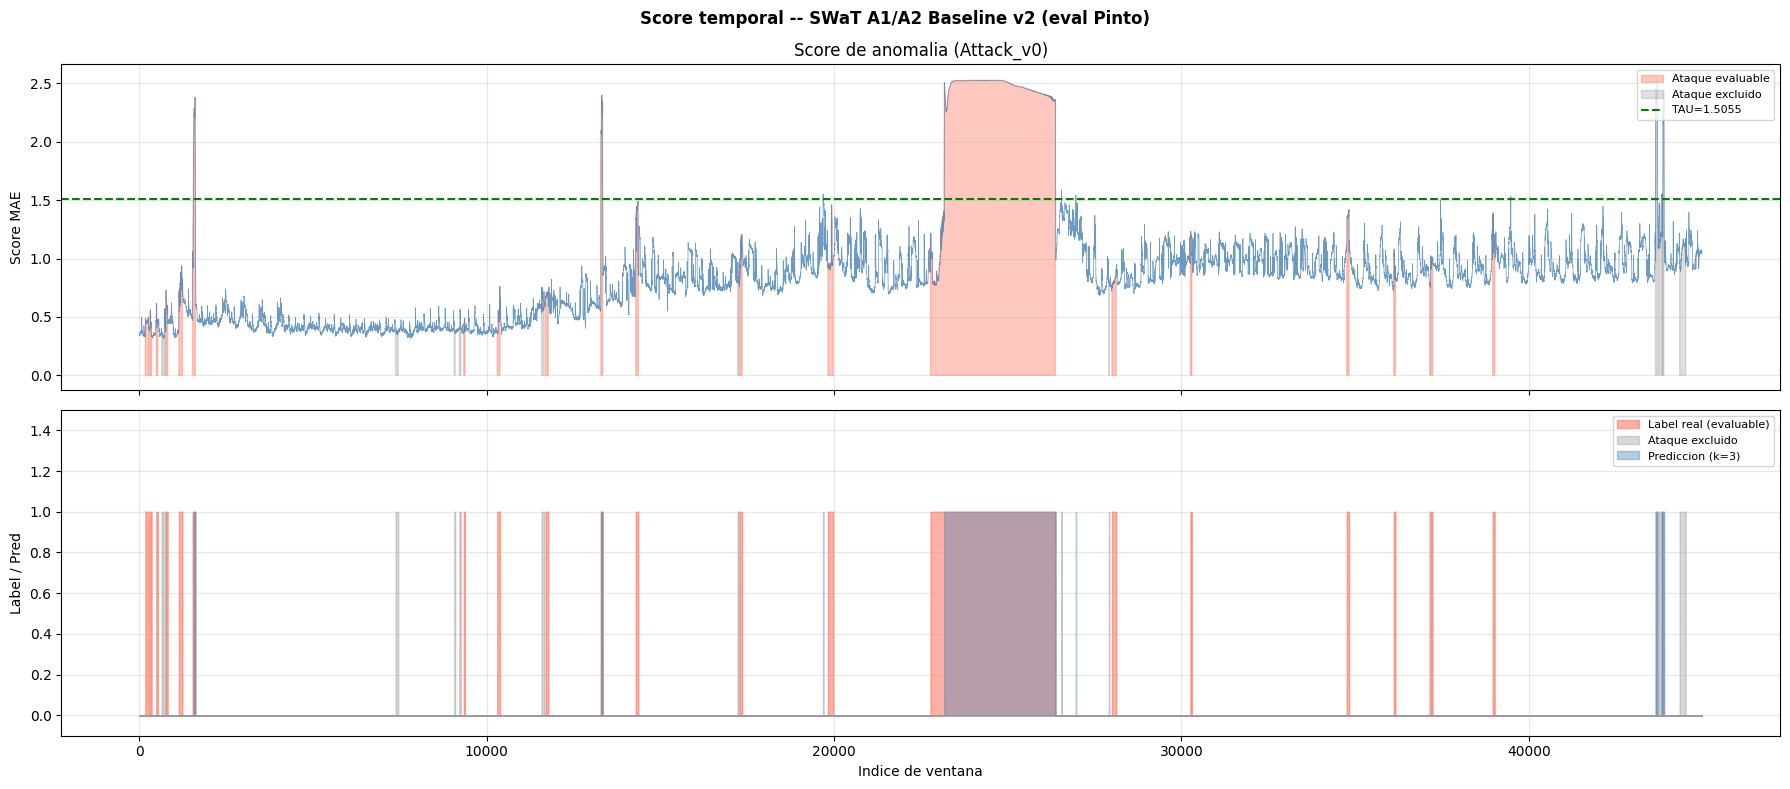

In [16]:
# Score temporal
t_idx     = np.arange(len(df_wins))
pred_all  = consec_filter(scores, TAU_OPT, CONSEC_K)
excl_mask = ((df_wins['y']==1) & (~df_wins['attack_id'].isin(EVALUABLE_ATK_IDS))).values

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
axes[0].plot(t_idx, scores, color='steelblue', lw=0.5, alpha=0.8)
axes[0].fill_between(t_idx, 0, scores, where=(y_all==1)&~excl_mask,
                     color='tomato', alpha=0.35, label='Ataque evaluable')
axes[0].fill_between(t_idx, 0, scores, where=excl_mask,
                     color='gray', alpha=0.25, label='Ataque excluido')
axes[0].axhline(TAU_OPT, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].set_ylabel('Score MAE'); axes[0].set_title('Score de anomalia (Attack_v0)')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(t_idx, 0, (y_all.astype(float))*(~excl_mask),
                     color='tomato', alpha=0.5, label='Label real (evaluable)')
axes[1].fill_between(t_idx, 0, excl_mask.astype(float),
                     color='gray', alpha=0.3, label='Ataque excluido')
axes[1].fill_between(t_idx, 0, pred_all.astype(float),
                     color='steelblue', alpha=0.4, label=f'Prediccion (k={CONSEC_K})')
axes[1].set_xlabel('Indice de ventana'); axes[1].set_ylabel('Label / Pred')
axes[1].set_ylim(-0.1, 1.5)
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Score temporal -- SWaT A1/A2 Baseline v2 (eval Pinto)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'score_temporal.png'), dpi=120, bbox_inches='tight')
plt.show()


## 9. Guardar artefactos

In [17]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(scores[y_all==0], p))
            for p in [90, 95, 97.5, 99, 99.5]}
tau_dict['optimal_k3'] = float(TAU_OPT)
with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)

with open(SAVE_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': CONTINUOUS_COLS,
               'discrete_cols':   DISCRETE_COLS}, f, indent=4)

config = {
    'version'          : 'lstm_vae_swat_a1a2_baseline_v2',
    'optuna_source'    : f'lstm_vae_swat_a1a2_optuna_v1 / trial #{ocfg["best_trial"]}',
    'dataset_train'    : 'SWaT_Dataset_Normal_v1.xlsx',
    'dataset_eval'     : 'SWaT_Dataset_Attack_v0.xlsx',
    'split'            : 'chronological_60_20_20',
    'window_size'      : WINDOW_SIZE,
    'stride'           : STRIDE,
    'clip_val'         : CLIP_VAL,
    'warmup_sec'       : WARMUP_SEC,
    'score_formula'    : 'alpha*MAE_cont + (1-alpha)*MAE_disc  (Pinto et al. 2024)',
    'n_continuous'     : len(CONTINUOUS_COLS),
    'n_discrete'       : len(DISCRETE_COLS),
    'disc_summary_dim' : DISC_DIM,
    'model_params'     : {
        'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
        'latent_dim' : LATENT_DIM,  'disc_hidden': DISC_HIDDEN,
        'alpha': ALPHA, 'beta': BETA, 'dropout': DROPOUT,
        'lr': LR, 'batch_size': BATCH_SIZE,
    },
    'training'         : {'best_epoch': best_ep, 'best_val_loss': float(best_val),
                          'n_windows_train': int(len(X_tr_c)),
                          'n_windows_val':   int(len(X_va_c))},
    'eval_protocol'    : {
        'consecutive_k'    : CONSEC_K,
        'tau_optimal'      : float(TAU_OPT),
        'excluded_attacks' : EXCLUDED_ATTACKS,
        'evaluable_attacks': EVALUABLE_ATK_IDS,
    },
    'metrics_ref'      : {
        'roc_auc_all'  : float(roc_auc_score(y_all, scores)),
        'ratio_atk'    : float(ma / mn),
    },
    'metrics_baseline' : {
        'roc_auc': float(auc_filt), 'pr_auc': float(pr_auc),
        'f1': float(f1), 'recall': float(rec),
        'precision': float(prec), 'fpr': float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    },
    'vs_baseline_v1'   : {
        'delta_auc': round(auc_filt - 0.8170, 4),
        'delta_f1' : round(f1 - 0.757, 3),
        'delta_rec': round(rec - 0.615, 3),
    },
    'continuous_cols'  : CONTINUOUS_COLS,
    'discrete_cols'    : DISCRETE_COLS,
    'scenarios'        : ['real_only', 'synthetic_only', 'real_plus_synthetic'],
}
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print('Artefactos guardados en:', SAVE_DIR.resolve())
for fp_ in sorted(SAVE_DIR.iterdir()): print(f'  {fp_.name}')
print()
print()
print('  Referencia Pinto et al. (2024): AUC=0.87 | F1=0.74 | Rec=0.78 | Prec=0.70')
print('='*65)
print('RESUMEN FINAL -- SWaT A1/A2 Baseline v2 (eval Pinto et al.)')
print('='*65)
print(f'  ROC-AUC   : {auc_filt:.4f}  |  PR-AUC    : {pr_auc:.4f}')
print(f'  F1        : {f1:.3f}   |  Recall    : {rec:.3f}')
print(f'  Precision : {prec:.3f}   |  FPR       : {fpr:.3f}')
print(f'  tau optimo: {TAU_OPT:.5f}  |  k         : {CONSEC_K}')
print(f'  Train wins: {len(X_tr_c):,}  |  Best ep   : {best_ep}')
print('='*65)


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_baseline_v2
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_referencia.png
  eval_dist_roc_pr.png
  model_state.pt
  scaler_cont.pkl
  score_temporal.png
  tau_dict.json
  tau_sweep.png
  training_curve.png


  Referencia Pinto et al. (2024): AUC=0.87 | F1=0.74 | Rec=0.78 | Prec=0.70
RESUMEN FINAL -- SWaT A1/A2 Baseline v2 (eval Pinto et al.)
  ROC-AUC   : 0.8603  |  PR-AUC    : 0.7756
  F1        : 0.798   |  Recall    : 0.668
  Precision : 0.992   |  FPR       : 0.001
  tau optimo: 1.50551  |  k         : 3
  Train wins: 29,587  |  Best ep   : 122
